In [3]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic visualization theme
sns.set(style="whitegrid")

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [4]:
df = pd.read_csv('/content/SpotifyFeatures.csv')

In [5]:
df.shape

(111821, 18)

In [6]:
df.head(5)

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373.0,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,04-Apr,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373.0,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,04-Apr,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267.0,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,05-Apr,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427.0,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,04-Apr,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625.0,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,04-Apr,0.390


In [7]:
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111821 entries, 0 to 111820
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             111821 non-null  object 
 1   artist_name       111821 non-null  object 
 2   track_name        111821 non-null  object 
 3   track_id          111821 non-null  object 
 4   popularity        111821 non-null  int64  
 5   acousticness      111821 non-null  float64
 6   danceability      111821 non-null  float64
 7   duration_ms       111820 non-null  float64
 8   energy            111820 non-null  float64
 9   instrumentalness  111820 non-null  float64
 10  key               111820 non-null  object 
 11  liveness          111820 non-null  float64
 12  loudness          111820 non-null  float64
 13  mode              111820 non-null  object 
 14  speechiness       111820 non-null  float64
 15  tempo             111820 non-null  float64
 16  time_signature    11

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,111821.000000,111821.000000,111821.000000,1.118200e+05,111820.000000,111820.000000,111820.000000,111820.000000,111820.000000,111820.000000,111820.000000
mean,42.206857,0.326880,0.564494,2.319986e+05,0.585735,0.117466,0.195478,-8.821778,0.092016,119.794250,0.455000
std,19.904721,0.345886,0.176272,9.730534e+04,0.256298,0.265212,0.162892,5.351000,0.102680,30.087038,0.247476
min,0.000000,0.000000,0.059200,1.538700e+04,0.000243,0.000000,0.009670,-47.046000,0.022200,32.080000,0.000000
25%,30.000000,0.024100,0.449000,1.861470e+05,0.406000,0.000000,0.097400,-10.822000,0.036300,95.501250,0.255000
50%,46.000000,0.173000,0.576000,2.212090e+05,0.615000,0.000062,0.127000,-7.356000,0.050000,119.625000,0.440000
75%,56.000000,0.611000,0.693000,2.631920e+05,0.798000,0.020200,0.245000,-5.228000,0.095700,139.983000,0.643000
max,100.000000,0.996000,0.989000,4.830606e+06,0.999000,0.997000,1.000000,3.744000,0.965000,242.903000,1.000000


In [8]:
df.dropna(inplace=True)
df.shape

(111820, 18)

In [9]:
df.drop_duplicates(inplace=True)
df['duration_min'] = df['duration_ms'] / 60000


In [10]:
#EDA Most Common Genres

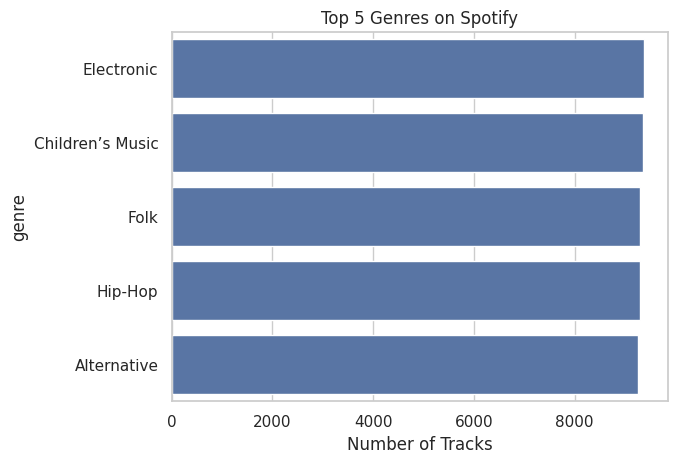

In [11]:
top_genres = df['genre'].value_counts().head(5)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 5 Genres on Spotify")
plt.xlabel("Number of Tracks")
plt.show()


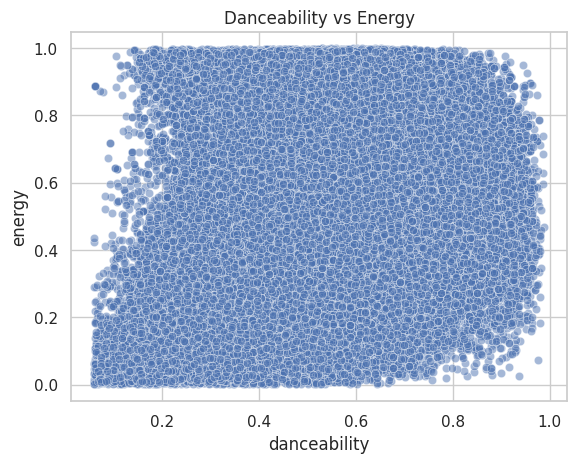

In [12]:
#Danceability vs Energy
sns.scatterplot(x='danceability', y='energy', data=df, alpha=0.5)
plt.title("Danceability vs Energy")
plt.show()

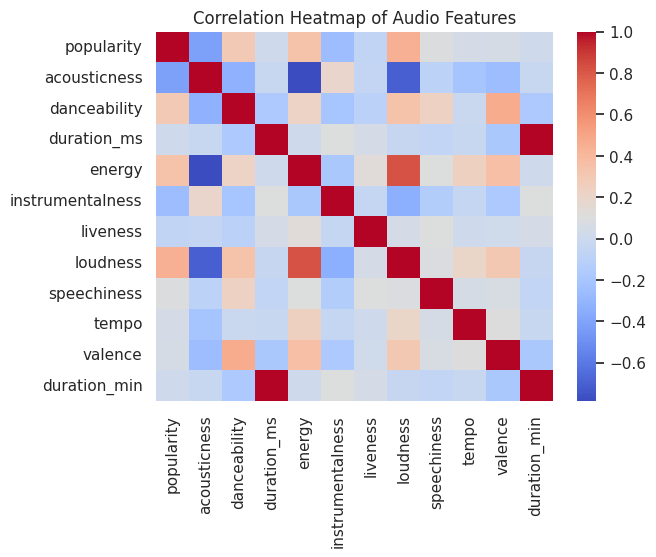

In [13]:
#Correlation Heatmap
#PURPOSE- To visually analyze how different audio features (like tempo, loudness, energy, etc.) are related to each other
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap of Audio Features")
plt.show()


/tmp/ipython-input-1178317274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_pop.values, y=genre_pop.index, palette='rocket')


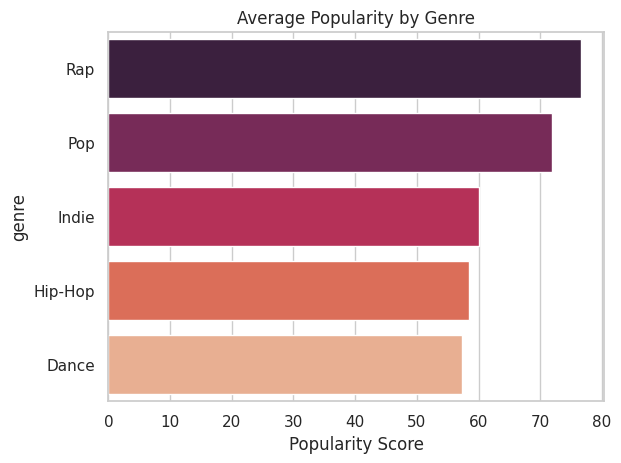

In [14]:
#Average Popularity by Genre
genre_pop = df.groupby('genre')['popularity'].mean().sort_values(ascending=False).head(5)
sns.barplot(x=genre_pop.values, y=genre_pop.index, palette='rocket')
plt.title("Average Popularity by Genre")
plt.xlabel("Popularity Score")
plt.show()


/tmp/ipython-input-2041572694.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_dur.values, y=genre_dur.index, palette='mako')


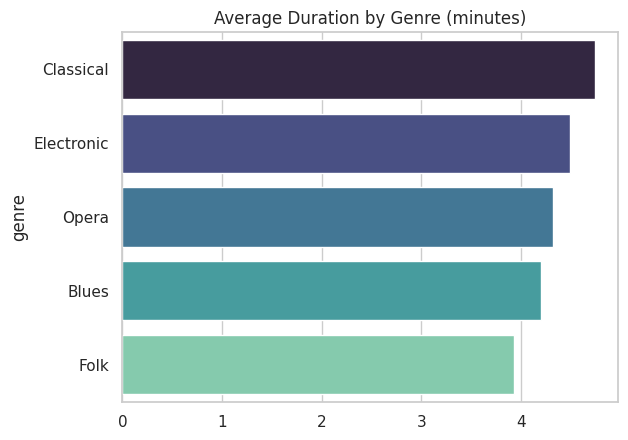

In [15]:
#Average Song Duration by Genre
df['duration_min'] = df['duration_ms'] / 60000
genre_dur = df.groupby('genre')['duration_min'].mean().sort_values(ascending=False).head(5)
sns.barplot(x=genre_dur.values, y=genre_dur.index, palette='mako')
plt.title("Average Duration by Genre (minutes)")
plt.show()


In [16]:
#SQL

In [17]:
import sqlite3   # library to use SQL in Python

# create a database in memory (temporary)
conn = sqlite3.connect('spotify.db')

# push our dataframe into this database
df.to_sql('spotify', conn, index=False, if_exists='replace')

print("SQL Database created with table 'spotify'")


SQL Database created with table 'spotify'


In [18]:
# Top 5 artists by average popularity
import pandas as pd

query = """
SELECT artist_name,
       ROUND(AVG(popularity),2) AS avg_popularity
FROM spotify
GROUP BY artist_name
ORDER BY avg_popularity DESC
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)
result


,artist_name,avg_popularity
0,Pedro Capó,97.0
1,Mau y Ricky,93.0
2,Sebastian Yatra,88.5
3,Silk City,87.0
4,Amenazzy,86.0


In [19]:
# Average energy & danceability per genre
query2 = """
SELECT genre,
       ROUND(AVG(energy),2) AS avg_energy,
       ROUND(AVG(danceability),2) AS avg_dance,
       ROUND(AVG(valence),2) AS avg_valence
FROM spotify
GROUP BY genre
ORDER BY avg_energy DESC
LIMIT 5;
"""
pd.read_sql_query(query2, conn)


,genre,avg_energy,avg_dance,avg_valence
0,Electronic,0.74,0.62,0.39
1,Children’s Music,0.71,0.54,0.45
2,Alternative,0.71,0.54,0.45
3,Dance,0.70,0.64,0.52
4,Anime,0.67,0.47,0.44


In [20]:
#Average duration by genre
query3 = """
SELECT genre,
       ROUND(AVG(duration_min),2) AS avg_duration_min
FROM spotify
GROUP BY genre
ORDER BY avg_duration_min DESC
LIMIT 5;
"""
pd.read_sql_query(query3, conn)


,genre,avg_duration_min
0,Classical,4.74
1,Electronic,4.49
2,Opera,4.32
3,Blues,4.20
4,Folk,3.93


In [21]:
# Top 5 most popular tracks overall
query4 = """
SELECT track_name, artist_name, popularity
FROM spotify
ORDER BY popularity DESC
LIMIT 5;
"""
pd.read_sql_query(query4, conn)


,track_name,artist_name,popularity
0,7 rings,Ariana Grande,100
1,7 rings,Ariana Grande,100
2,"break up with your girlfriend, i'm bored",Ariana Grande,99
3,Wow.,Post Malone,99
4,"break up with your girlfriend, i'm bored",Ariana Grande,99


In [22]:
#Export Data For Tableau

In [23]:
df[['genre','artist_name','track_name','popularity','danceability',
    'energy','valence','acousticness','tempo','duration_min']].to_csv('/content/spotify_for_tableau.csv', index=False)

print(" Exported spotify_for_tableau.csv for Tableau")


 Exported spotify_for_tableau.csv for Tableau


In [24]:
# Export SQL summary table (genre insights)
sql_result = pd.read_sql_query("""
SELECT genre,
       ROUND(AVG(energy),2) AS avg_energy,
       ROUND(AVG(danceability),2) AS avg_dance,
       ROUND(AVG(valence),2) AS avg_valence,
       ROUND(AVG(popularity),2) AS avg_popularity
FROM spotify
GROUP BY genre
ORDER BY avg_popularity DESC;
""", conn)

sql_result.to_csv('/content/spotify_genre_summary.csv', index=False)
print("Exported spotify_genre_summary.csv for Tableau")


Exported spotify_genre_summary.csv for Tableau
